In [1]:
# Load engineered feature dataset (561 features) and labels
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

DATASET_PATH = "./UCI HAR Dataset"

# Load features list
features = pd.read_csv(os.path.join(DATASET_PATH, "features.txt"), sep=r"\s+", header=None)
feature_names = features[1].values

# Load activity labels
labels = pd.read_csv(os.path.join(DATASET_PATH, "activity_labels.txt"), sep=r"\s+", header=None)
activity_map = dict(zip(labels[0], labels[1]))

# Load train/test engineered data
X_train = pd.read_csv(os.path.join(DATASET_PATH,"train","X_train.txt"), sep=r"\s+", header=None)
X_test  = pd.read_csv(os.path.join(DATASET_PATH,"test","X_test.txt"),  sep=r"\s+", header=None)
y_train = pd.read_csv(os.path.join(DATASET_PATH,"train","y_train.txt"), header=None)
y_test  = pd.read_csv(os.path.join(DATASET_PATH,"test","y_test.txt"),  header=None)

# Assign column names
X_train.columns = feature_names
X_test.columns  = feature_names

# Map activity IDs to names
y_train = y_train[0].map(activity_map)
y_test  = y_test[0].map(activity_map)

# Merge train + test
X = pd.concat([X_train, X_test], axis=0)
y = pd.concat([y_train, y_test], axis=0)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (10299, 561)
y shape: (10299,)


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

# 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=0.30,
    stratify=y_enc,
    random_state=42
)

# Standardize features (fit ONLY on train)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Classes:", list(le.classes_))
print("Train shape:", X_train_s.shape)
print("Test shape:", X_test_s.shape)


Classes: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
Train shape: (7209, 561)
Test shape: (3090, 561)


In [3]:
# -------------------------------
# Section 1: MLP Data Preparation (Train + Test only)
# -------------------------------
import os
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# Load filtered features (UCI HAR already provides train/test split)
X_train = np.loadtxt(os.path.join(DATASET_PATH, "train", "X_train.txt"))
y_train = np.loadtxt(os.path.join(DATASET_PATH, "train", "y_train.txt")).astype(int) - 1

X_test  = np.loadtxt(os.path.join(DATASET_PATH, "test", "X_test.txt"))
y_test  = np.loadtxt(os.path.join(DATASET_PATH, "test", "y_test.txt")).astype(int) - 1

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

# Create DataLoaders
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=64,
    shuffle=False
)

print("MLP Data Shapes:")
print("Train:", X_train_t.shape, y_train_t.shape)
print("Test :", X_test_t.shape, y_test_t.shape)


MLP Data Shapes:
Train: torch.Size([7352, 561]) torch.Size([7352])
Test : torch.Size([2947, 561]) torch.Size([2947])


In [4]:
# -------------------------------
# Section 2: MLP Model Definition & Training (Train only)
# -------------------------------
import torch.nn as nn
import torch.optim as optim

# Define MLP
class MLP(nn.Module):
    def __init__(self, input_dim=561, num_classes=6):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Instantiate model, loss, optimizer
mlp_model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3)

# Training loop (no validation, train set only)
num_epochs = 20
for epoch in range(num_epochs):
    mlp_model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = mlp_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Training Loss: {epoch_loss:.4f}")


Epoch [1/20] - Training Loss: 0.7666
Epoch [2/20] - Training Loss: 0.2421
Epoch [3/20] - Training Loss: 0.1611
Epoch [4/20] - Training Loss: 0.1097
Epoch [5/20] - Training Loss: 0.1030
Epoch [6/20] - Training Loss: 0.0889
Epoch [7/20] - Training Loss: 0.0735
Epoch [8/20] - Training Loss: 0.0637
Epoch [9/20] - Training Loss: 0.0658
Epoch [10/20] - Training Loss: 0.0765
Epoch [11/20] - Training Loss: 0.0537
Epoch [12/20] - Training Loss: 0.0499
Epoch [13/20] - Training Loss: 0.0463
Epoch [14/20] - Training Loss: 0.0474
Epoch [15/20] - Training Loss: 0.0482
Epoch [16/20] - Training Loss: 0.0559
Epoch [17/20] - Training Loss: 0.0405
Epoch [18/20] - Training Loss: 0.0442
Epoch [19/20] - Training Loss: 0.0453
Epoch [20/20] - Training Loss: 0.0520


Test Set Accuracy: 0.9471
Test Set F1 Score: 0.9472


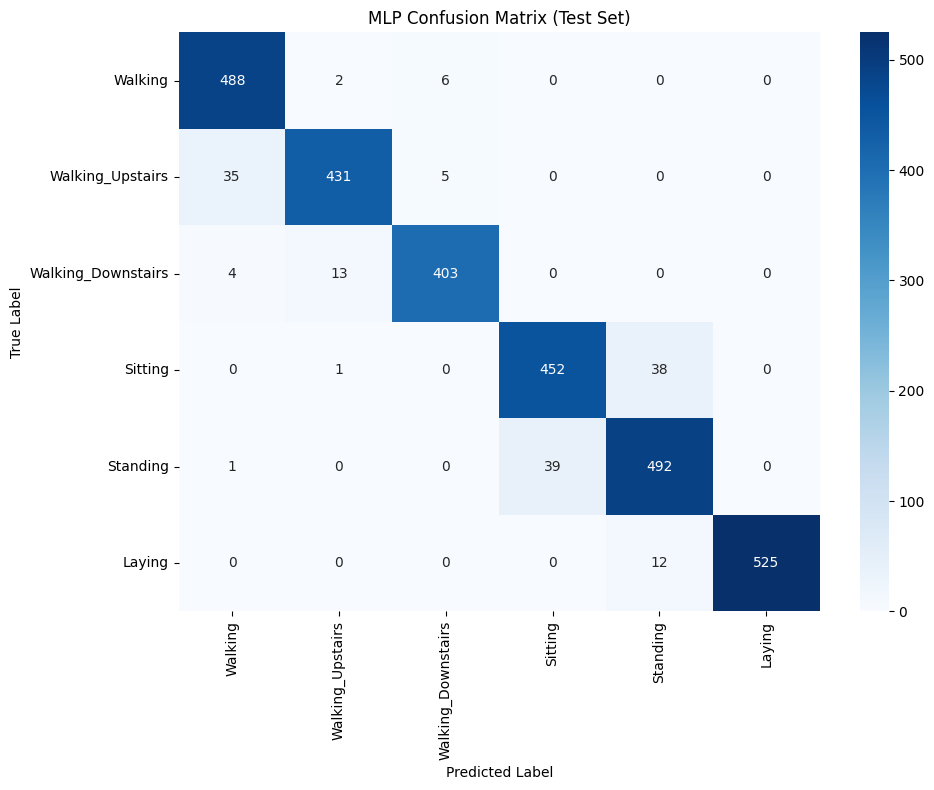

In [8]:
# ---------------------------------------------------------
# Section 3: MLP Evaluation 
# ---------------------------------------------------------
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Human-readable class names (UCI HAR)
class_names = [
    'Walking', 'Walking_Upstairs', 'Walking_Downstairs',
    'Sitting', 'Standing', 'Laying'
]

mlp_model.eval()

def evaluate_and_plot(loader, title, filename):
    y_pred = []
    y_true = loader.dataset.tensors[1].numpy()

    with torch.no_grad():
        for X_batch, _ in loader:
            outputs = mlp_model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            y_pred.extend(preds.cpu().numpy())

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')

    print(f"{title} Accuracy: {acc:.4f}")
    print(f"{title} F1 Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"MLP Confusion Matrix ({title})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()

    # Save for report
    plt.savefig(f"{filename}.pdf", format="pdf")
    plt.show()


# ----- Test set evaluation only -----
evaluate_and_plot(
    test_loader,
    title="Test Set",
    filename="MLP_Confusion_Matrix_Test"
)


In [9]:
# ---------------------------------------------------------
# Section 4: CNN Data Preparation (RAW signals – Train & Test ONLY)
# ---------------------------------------------------------
import os
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# Dataset root
DATASET_PATH = os.path.join(".", "UCI HAR Dataset")

def load_raw_signals(subset):
    """
    Loads raw inertial signals and returns shape:
    (samples, 128 timesteps, 9 channels)
    """
    path = os.path.join(DATASET_PATH, subset, "Inertial Signals")

    files = [
        "body_acc_x_", "body_acc_y_", "body_acc_z_",
        "body_gyro_x_", "body_gyro_y_", "body_gyro_z_",
        "total_acc_x_", "total_acc_y_", "total_acc_z_"
    ]

    signals = []
    for f in files:
        full_path = os.path.join(path, f"{f}{subset}.txt")
        signals.append(np.loadtxt(full_path))

    # (samples, 128, 9)
    return np.stack(signals, axis=2)


# -------------------------------
# Load RAW signals (CNN input)
# -------------------------------
X_train_raw = load_raw_signals("train")
y_train_raw = np.loadtxt(
    os.path.join(DATASET_PATH, "train", "y_train.txt")
).astype(int) - 1

X_test_raw = load_raw_signals("test")
y_test_raw = np.loadtxt(
    os.path.join(DATASET_PATH, "test", "y_test.txt")
).astype(int) - 1


# -------------------------------
# Convert to PyTorch tensors
# CNN expects (batch, channels, timesteps)
# -------------------------------
X_train_t = torch.tensor(X_train_raw, dtype=torch.float32).permute(0, 2, 1)
y_train_t = torch.tensor(y_train_raw, dtype=torch.long)

X_test_t = torch.tensor(X_test_raw, dtype=torch.float32).permute(0, 2, 1)
y_test_t = torch.tensor(y_test_raw, dtype=torch.long)


# -------------------------------
# DataLoaders
# -------------------------------
train_loader_raw = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=64,
    shuffle=True
)

test_loader_raw = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=64,
    shuffle=False
)


print("CNN Data Shapes (batch, channels, timesteps):")
print("Train:", X_train_t.shape)
print("Test :", X_test_t.shape)


CNN Data Shapes (batch, channels, timesteps):
Train: torch.Size([7352, 9, 128])
Test : torch.Size([2947, 9, 128])


In [ ]:
# -------------------------------
# Section 2: CNN Definition & Training
# -------------------------------
import torch
import torch.nn as nn
import torch.optim as optim

# Define 1D CNN
class CNN(nn.Module):
    def __init__(self, num_classes=6):
        super(CNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=9, out_channels=64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 16, 128),  # 128 → 64 → 32 → 16
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x shape: (batch, 9, 128)
        x = self.conv(x)
        x = self.fc(x)
        return x


# Instantiate model, loss, optimizer
cnn_model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3)


# -------------------------------
# Training loop (train set only)
# -------------------------------
num_epochs = 20

for epoch in range(num_epochs):
    cnn_model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader_raw:
        optimizer.zero_grad()
        outputs = cnn_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_loader_raw.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Training Loss: {epoch_loss:.4f}")


Epoch [1/20] - Training Loss: 0.3079
Epoch [2/20] - Training Loss: 0.1490
Epoch [3/20] - Training Loss: 0.1315
Epoch [4/20] - Training Loss: 0.1217
Epoch [5/20] - Training Loss: 0.1221
Epoch [6/20] - Training Loss: 0.1290
Epoch [7/20] - Training Loss: 0.1260
Epoch [8/20] - Training Loss: 0.1289
Epoch [9/20] - Training Loss: 0.1156
Epoch [10/20] - Training Loss: 0.1191
Epoch [11/20] - Training Loss: 0.1047
Epoch [12/20] - Training Loss: 0.1111
Epoch [13/20] - Training Loss: 0.1030
Epoch [14/20] - Training Loss: 0.1005
Epoch [15/20] - Training Loss: 0.1036
Epoch [16/20] - Training Loss: 0.0882
Epoch [17/20] - Training Loss: 0.1012
Epoch [18/20] - Training Loss: 0.0883
Epoch [19/20] - Training Loss: 0.0943
Epoch [20/20] - Training Loss: 0.0948


Test Set - Accuracy: 0.9318, F1 Score: 0.9315


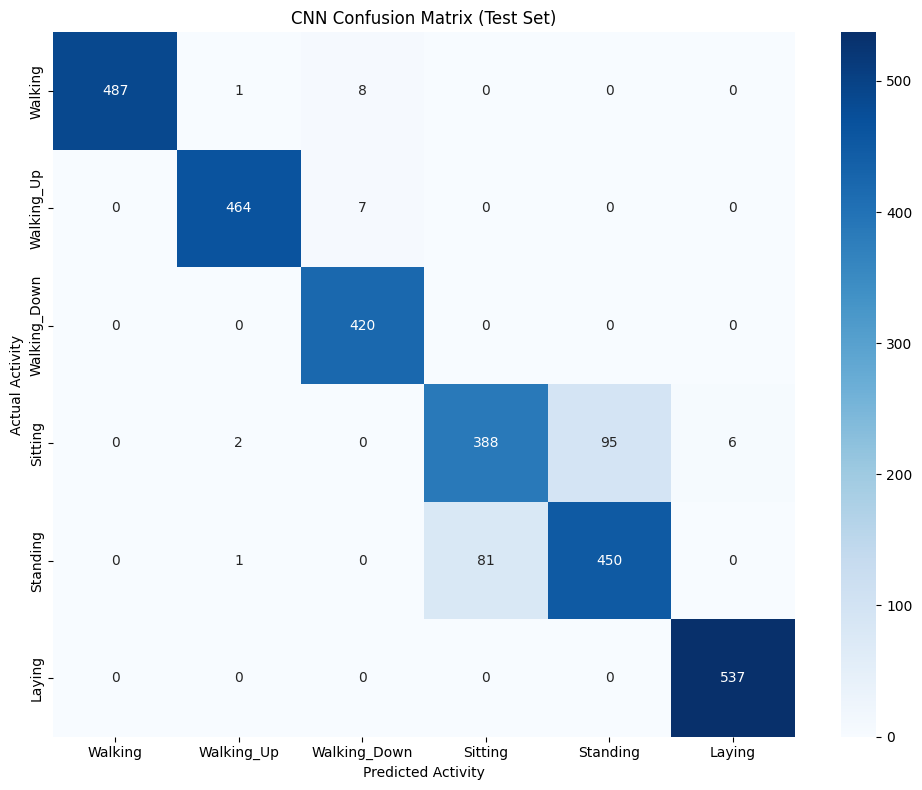

In [11]:
# ---------------------------------------------------------
# Section 3: CNN Evaluation 
# ---------------------------------------------------------
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Human-readable activity names
class_names = ['Walking', 'Walking_Up', 'Walking_Down', 'Sitting', 'Standing', 'Laying']

cnn_model.eval()  # Set model to evaluation mode

def evaluate_and_plot_cnn(loader, y_true, title, filename):
    y_pred = []
    with torch.no_grad():
        for X_batch, _ in loader:
            outputs = cnn_model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            y_pred.extend(preds.numpy())

    # Accuracy & F1
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"{title} - Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"CNN Confusion Matrix ({title})")
    plt.xlabel("Predicted Activity")
    plt.ylabel("Actual Activity")
    plt.tight_layout()
    plt.savefig(f"{filename}.pdf", format='pdf') 
    plt.show()

# ----- Test Set Evaluation -----
evaluate_and_plot_cnn(test_loader_raw, y_test_raw, "Test Set", "CNN_Confusion_Matrix_Test")
